<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-ML/blob/main/ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Dataset/tested.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
413,False,False,False,False,False,True,False,False,False,False,True,False
414,False,False,False,False,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False,False,False,True,False
416,False,False,False,False,False,True,False,False,False,False,True,False


In [6]:
col_sum = df['Age'].sum(axis=0)
print("Sum: ", col_sum)

Sum:  10050.5


In [7]:
df['Age'].isnull()

,Age
0,False
1,False
2,False
3,False
4,False
...,...
413,True
414,False
415,False
416,True


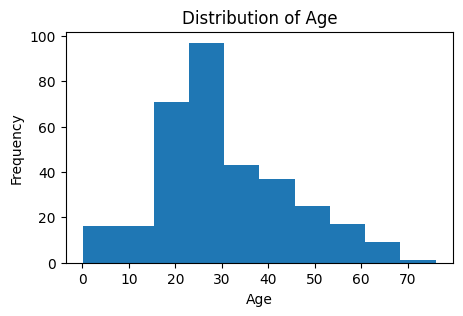

In [8]:
plt.figure(figsize=(5,3))
plt.hist(df['Age'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputed_data = imputer.fit_transform(df[['Age']])
print("Before Imputation:")
print(df['Age'])
df['Age'] = imputed_data
print("\nAfter Imputation:")
print(df['Age'])

Before Imputation:
0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413     NaN
414    39.0
415    38.5
416     NaN
417     NaN
Name: Age, Length: 418, dtype: float64

After Imputation:
0      34.50000
1      47.00000
2      62.00000
3      27.00000
4      22.00000
         ...   
413    30.27259
414    39.00000
415    38.50000
416    30.27259
417    30.27259
Name: Age, Length: 418, dtype: float64


In [10]:
#using fillna to fill a single null value
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [11]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Sex'].head()

,Sex
0,1
1,0
2,1
3,1
4,0


In [13]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
ohetransform = ohe.fit_transform(df[['Pclass']])
ohetransform.head()

,Pclass_1,Pclass_2,Pclass_3
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [14]:
df = pd.concat([df, ohetransform], axis=1).drop(columns="Pclass")

In [15]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked,Pclass_1,Pclass_2,Pclass_3
0,0,1,34.5,0,0,7.8292,Q,0.0,0.0,1.0
1,1,0,47.0,1,0,7.0000,S,0.0,0.0,1.0
2,0,1,62.0,0,0,9.6875,Q,0.0,1.0,0.0
3,0,1,27.0,0,0,8.6625,S,0.0,0.0,1.0
4,1,0,22.0,1,1,12.2875,S,0.0,0.0,1.0


In [16]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
ohetransform = ohe.fit_transform(df[["Embarked"]])
ohetransform.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [17]:
df = pd.concat([df, ohetransform], axis=1).drop(columns="Embarked")

In [18]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,0,1,34.5,0,0,7.8292,0.0,0.0,1.0,0.0,1.0,0.0
1,1,0,47.0,1,0,7.0000,0.0,0.0,1.0,0.0,0.0,1.0
2,0,1,62.0,0,0,9.6875,0.0,1.0,0.0,0.0,1.0,0.0
3,0,1,27.0,0,0,8.6625,0.0,0.0,1.0,0.0,0.0,1.0
4,1,0,22.0,1,1,12.2875,0.0,0.0,1.0,0.0,0.0,1.0


In [19]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [20]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0.452723,0.000,0.000000,0.015282,0.0,0.0,1.0,0.0,1.0,0.0
1,1,0,0.617566,0.125,0.000000,0.013663,0.0,0.0,1.0,0.0,0.0,1.0
2,0,1,0.815377,0.000,0.000000,0.018909,0.0,1.0,0.0,0.0,1.0,0.0
3,0,1,0.353818,0.000,0.000000,0.016908,0.0,0.0,1.0,0.0,0.0,1.0
4,1,0,0.287881,0.125,0.111111,0.023984,0.0,0.0,1.0,0.0,0.0,1.0


In [21]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0.452723,0.000,0.000000,0.015282,0.0,0.0,1.0,0.0,1.0,0.0
1,1,0,0.617566,0.125,0.000000,0.013663,0.0,0.0,1.0,0.0,0.0,1.0
2,0,1,0.815377,0.000,0.000000,0.018909,0.0,1.0,0.0,0.0,1.0,0.0
3,0,1,0.353818,0.000,0.000000,0.016908,0.0,0.0,1.0,0.0,0.0,1.0
4,1,0,0.287881,0.125,0.111111,0.023984,0.0,0.0,1.0,0.0,0.0,1.0


In [22]:
from sklearn.model_selection import train_test_split

x = df[["Sex","Age","SibSp","Parch","Fare","Pclass_1","Pclass_2","Pclass_3","Embarked_C","Embarked_Q","Embarked_S"]]
y = df["Survived"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
x_train,y_train

(     Sex       Age  SibSp  Parch      Fare  Pclass_1  Pclass_2  Pclass_3  \
 336    1  0.419755  0.000    0.0  0.025374       0.0       1.0       0.0   
 31     1  0.314256  0.250    0.0  0.061484       0.0       1.0       0.0   
 84     1  0.396975  0.000    0.0  0.020901       0.0       1.0       0.0   
 287    1  0.314256  0.125    0.0  0.160574       1.0       0.0       0.0   
 317    1  0.248319  0.000    0.0  0.020495       0.0       1.0       0.0   
 ..   ...       ...    ...    ...       ...       ...       ...       ...   
 71     1  0.274693  0.000    0.0  0.015412       0.0       0.0       1.0   
 106    1  0.274693  0.000    0.0  0.015265       0.0       0.0       1.0   
 270    1  0.604378  0.000    0.0  0.146862       1.0       0.0       0.0   
 348    1  0.314256  0.000    0.0  0.026350       0.0       1.0       0.0   
 102    1  0.396975  0.000    0.0  0.015127       0.0       0.0       1.0   
 
      Embarked_C  Embarked_Q  Embarked_S  
 336         0.0         0.0   

In [24]:
x_test,y_test

(     Sex       Age  SibSp     Parch      Fare  Pclass_1  Pclass_2  Pclass_3  \
 321    1  0.327443  0.000  0.000000  0.014110       0.0       0.0       1.0   
 324    0  0.512066  0.000  0.000000  0.412503       1.0       0.0       0.0   
 388    1  0.274693  0.000  0.000000  0.015127       0.0       0.0       1.0   
 56     1  0.459317  0.000  0.000000  0.015412       0.0       0.0       1.0   
 153    0  0.472504  0.000  0.222222  0.023780       0.0       0.0       1.0   
 ..   ...       ...    ...       ...       ...       ...       ...       ...   
 57     1  0.327443  0.000  0.000000  0.014932       0.0       0.0       1.0   
 126    1  0.287881  0.000  0.000000  0.015216       0.0       0.0       1.0   
 24     0  0.630753  0.125  0.333333  0.512122       1.0       0.0       0.0   
 17     1  0.274693  0.000  0.000000  0.014102       0.0       0.0       1.0   
 66     0  0.235131  0.000  0.000000  0.015379       0.0       0.0       1.0   
 
      Embarked_C  Embarked_Q  Embarked